In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score


In [8]:
df = pd.read_csv("https://raw.githubusercontent.com/ananyaghorpade29/titanic/refs/heads/main/data/Titanic-Dataset.csv")
df.head()
x= df.drop("Survived",axis=1)
y= df["Survived"]

categorical_cols = ["Sex", "Embarked"]
numerical_cols = ["Age", "Fare", "Pclass", "SibSp", "Parch"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

pipeline= Pipeline([
    ("preprocessor",preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
#Baseline Model
baseline_pred = pipeline.predict(x_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy: ",baseline_acc)


Baseline Accuracy:  0.8100558659217877


In [ ]:
#GridSearchCV (Tuning)
param_grid = {
    "model__n_estimators": [50,100,200], #“Since the model is inside a pipeline,
    "model__max_depth": [None, 5,10,20], # we use double underscore (model__param) to tune hyperparameters.”
    "model__min_samples_split": [2,5,10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train,y_train)

#Best Params + CV Score
print("Best Params: ", grid_search.best_params_)
print("Best CV Score: ",grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params:  {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV Score:  0.8272037821333595


In [14]:
#Compare with Baseline
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
tuned_acc = accuracy_score(y_test, y_pred)

print("Tuned Accuracy: ",tuned_acc)
print("Improvements: ",tuned_acc-baseline_acc)


Tuned Accuracy:  0.8100558659217877
Improvements:  0.0


In [16]:
#. RandomizedSearchCV (Faster ⚡)
param_dist = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10, 15]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(x_train, y_train)

print("Random Best Params:", random_search.best_params_)
print("Random Best Score:", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Best Params: {'model__n_estimators': 200, 'model__min_samples_split': 15, 'model__max_depth': 5}
Random Best Score: 0.8244065793361568


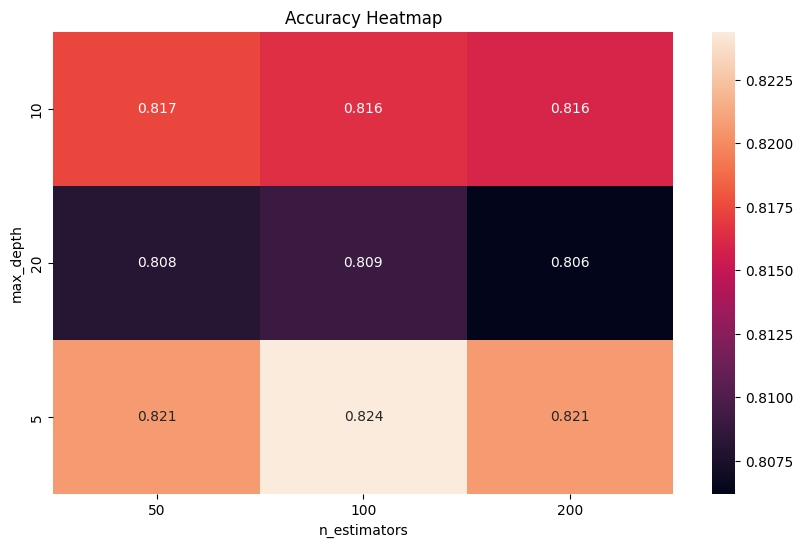

In [17]:
#Heatmap (max_depth vs n_estimators)
results = pd.DataFrame(grid_search.cv_results_)

results["param_model__max_depth"] = results["param_model__max_depth"].astype(str)

pivot = results.pivot_table(
    values="mean_test_score",
    index="param_model__max_depth",
    columns="param_model__n_estimators"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f")

plt.title("Accuracy Heatmap")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")

plt.show()